In [1]:
# Install required packages
!pip install opencv-python matplotlib scipy numpy

import numpy as np
import cv2
import matplotlib.pyplot as plt
from scipy.ndimage import sobel, gaussian_filter, uniform_filter
from scipy.ndimage.filters import convolve
import time
from scipy import ndimage
import os
import urllib.request

/tmp/ipython-input-3622545025.py:8: DeprecationWarning: Please import `convolve` from the `scipy.ndimage` namespace; the `scipy.ndimage.filters` namespace is deprecated and will be removed in SciPy 2.0.0.
  from scipy.ndimage.filters import convolve


In [2]:
def harris_corners_improved(gray_img, block_size=3, ksize=3, k=0.04,
                           suppression_radius=3, percentile_threshold=95,
                           top_n=None, subpixel=True):
    """
    Improved Harris Corner Detector with all requested enhancements.
    """
    # Convert to float for processing
    if gray_img.dtype != np.float32:
        gray_img = gray_img.astype(np.float32)

    # Step 1: Compute gradients
    kernel_x = np.array([[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]], dtype=np.float32)
    kernel_y = np.array([[-1, -1, -1], [0, 0, 0], [1, 1, 1]], dtype=np.float32)

    Ix = convolve(gray_img, kernel_x, mode='constant')
    Iy = convolve(gray_img, kernel_y, mode='constant')

    # Step 2: Compute structure tensor components
    Ixx = Ix * Ix
    Iyy = Iy * Iy
    Ixy = Ix * Iy

    # Step 3: Efficient window summation using uniform_filter
    Sxx = uniform_filter(Ixx, size=block_size, mode='constant') * (block_size * block_size)
    Syy = uniform_filter(Iyy, size=block_size, mode='constant') * (block_size * block_size)
    Sxy = uniform_filter(Ixy, size=block_size, mode='constant') * (block_size * block_size)

    # Step 4: Compute Harris response
    det_M = Sxx * Syy - Sxy * Sxy
    trace_M = Sxx + Syy
    R = det_M - k * (trace_M ** 2)

    # Step 5: Adaptive thresholding
    threshold = np.percentile(R, percentile_threshold)
    corner_mask = R > threshold

    # Step 6: Non-maximum suppression
    y_coords, x_coords = np.where(corner_mask)

    candidates = []
    for y, x in zip(y_coords, x_coords):
        candidates.append((y, x, R[y, x]))

    candidates.sort(key=lambda x: x[2], reverse=True)

    kept_corners = []
    for y, x, score in candidates:
        keep = True
        for ky, kx, _ in kept_corners:
            if np.sqrt((y - ky)**2 + (x - kx)**2) <= suppression_radius:
                keep = False
                break

        if keep:
            kept_corners.append((y, x, score))

    # Step 7: Sub-pixel refinement
    refined_corners = []
    for y, x, score in kept_corners:
        if subpixel and 1 < y < R.shape[0]-2 and 1 < x < R.shape[1]-2:
            patch = R[y-1:y+2, x-1:x+2]
            dx = (patch[1, 2] - patch[1, 0]) / (2 * (2 * patch[1, 1] - patch[1, 2] - patch[1, 0] + 1e-8))
            dy = (patch[2, 1] - patch[0, 1]) / (2 * (2 * patch[1, 1] - patch[2, 1] - patch[0, 1] + 1e-8))

            x_refined = x + dx
            y_refined = y + dy

            x_refined = max(0, min(x_refined, R.shape[1]-1))
            y_refined = max(0, min(y_refined, R.shape[0]-1))

            refined_corners.append((y_refined, x_refined, score))
        else:
            refined_corners.append((float(y), float(x), score))

    # Step 8: Return top N corners
    if top_n is not None and top_n > 0:
        refined_corners = refined_corners[:top_n]

    return refined_corners

In [3]:
def multi_scale_harris(gray_img, scales=[1.0, 1.5, 2.0],
                       base_block_size=3, k=0.04,
                       suppression_radius=5, percentile_threshold=95):
    """
    Multi-scale Harris corner detector.
    """
    corners_all_scales = []

    for scale in scales:
        sigma = scale
        img_smooth = gaussian_filter(gray_img.astype(np.float32), sigma=sigma)

        block_size = int(base_block_size * scale)
        if block_size % 2 == 0:
            block_size += 1

        corners = harris_corners_improved(
            img_smooth,
            block_size=block_size,
            k=k,
            suppression_radius=int(suppression_radius * scale),
            percentile_threshold=percentile_threshold,
            subpixel=True,
            top_n=None
        )

        for y, x, response in corners:
            corners_all_scales.append((y, x, response, scale))

    # Remove duplicates across scales
    final_corners = []
    merge_radius = 5

    corners_all_scales.sort(key=lambda x: x[2], reverse=True)

    for y, x, response, scale in corners_all_scales:
        keep = True
        for fy, fx, _, _ in final_corners:
            if np.sqrt((y - fy)**2 + (x - fx)**2) < merge_radius:
                keep = False
                break

        if keep:
            final_corners.append((y, x, response, scale))

    return final_corners

In [4]:
def fast_corners_improved(gray_img, threshold=20, n=9,
                         suppression_radius=3, top_n=None,
                         do_nms=True, score_method="original"):
    """
    Improved FAST detector with scoring and non-max suppression.
    """
    if gray_img.dtype != np.uint8:
        gray_img = gray_img.astype(np.uint8)

    height, width = gray_img.shape
    corners = []

    # Bresenham circle of radius 3 (16 pixels)
    circle = [
        (0, 3), (1, 3), (2, 2), (3, 1), (3, 0), (3, -1), (2, -2), (1, -3),
        (0, -3), (-1, -3), (-2, -2), (-3, -1), (-3, 0), (-3, 1), (-2, 2), (-1, 3)
    ]

    circle_idx = [(dy, dx) for dy, dx in circle]

    for y in range(3, height - 3):
        for x in range(3, width - 3):
            center = int(gray_img[y, x])

            # Fast check: Check points at 0, 4, 8, 12 first
            test_points = [0, 4, 8, 12]
            bright_count = 0
            dark_count = 0

            for idx in test_points:
                dy, dx = circle_idx[idx]
                p = int(gray_img[y + dy, x + dx])
                if p > center + threshold:
                    bright_count += 1
                elif p < center - threshold:
                    dark_count += 1

            # Quick rejection
            if bright_count < 3 and dark_count < 3:
                continue

            # Full circle test
            consec_bright = 0
            consec_dark = 0
            max_consec_b = 0
            max_consec_d = 0

            for dy, dx in circle_idx:
                p = int(gray_img[y + dy, x + dx])

                if p > center + threshold:
                    consec_bright += 1
                    consec_dark = 0
                    max_consec_b = max(max_consec_b, consec_bright)
                elif p < center - threshold:
                    consec_dark += 1
                    consec_bright = 0
                    max_consec_d = max(max_consec_d, consec_dark)
                else:
                    consec_bright = 0
                    consec_dark = 0

            # Check if it's a corner
            if max_consec_b >= n or max_consec_d >= n:
                # Compute score
                if score_method == "sum_abs_diff":
                    score = 0
                    for dy, dx in circle_idx:
                        p = int(gray_img[y + dy, x + dx])
                        if abs(p - center) > threshold:
                            score += abs(p - center)
                else:
                    score = max_consec_b + max_consec_d

                corners.append((y, x, score))

    # Apply non-maximum suppression if requested
    if do_nms and corners:
        corners = non_max_suppression_fast(corners, suppression_radius)

    # Sort by score
    corners.sort(key=lambda x: x[2], reverse=True)

    # Return top N if requested
    if top_n is not None and top_n > 0:
        corners = corners[:top_n]

    return corners

def non_max_suppression_fast(corners, radius=3):
    """Non-max suppression for FAST corners."""
    if not corners:
        return []

    corners_sorted = sorted(corners, key=lambda x: x[2], reverse=True)
    suppressed = []

    for y, x, score in corners_sorted:
        keep = True
        for sy, sx, _ in suppressed:
            if np.sqrt((y - sy)**2 + (x - sx)**2) <= radius:
                keep = False
                break

        if keep:
            suppressed.append((y, x, score))

    return suppressed

In [5]:
def multi_scale_fast(gray_img, scales=[1.0, 0.75, 0.5],
                     base_threshold=20, n=9, top_n=200):
    """
    Multi-scale FAST detector.
    """
    if gray_img.dtype != np.uint8:
        gray_img = gray_img.astype(np.uint8)

    all_corners = []

    for scale in scales:
        if scale == 1.0:
            img_scaled = gray_img
        else:
            new_height = int(gray_img.shape[0] * scale)
            new_width = int(gray_img.shape[1] * scale)
            img_scaled = cv2.resize(gray_img, (new_width, new_height),
                                   interpolation=cv2.INTER_AREA)

        threshold = int(base_threshold * scale)

        corners = fast_corners_improved(
            img_scaled,
            threshold=threshold,
            n=n,
            suppression_radius=max(3, int(3 * scale)),
            top_n=top_n,
            do_nms=True,
            score_method="sum_abs_diff"
        )

        for y, x, score in corners:
            y_orig = y / scale
            x_orig = x / scale
            all_corners.append((y_orig, x_orig, score, scale))

    # Merge corners across scales
    final_corners = []
    merge_radius = 10

    all_corners.sort(key=lambda x: x[2], reverse=True)

    for y, x, score, scale in all_corners:
        keep = True
        for fy, fx, _, _ in final_corners:
            if np.sqrt((y - fy)**2 + (x - fx)**2) < merge_radius:
                keep = False
                break

        if keep:
            final_corners.append((y, x, score, scale))

    return final_corners

In [6]:
def shi_tomasi_corners(gray_img, block_size=3, ksize=3,
                      suppression_radius=3, percentile_threshold=95,
                      top_n=None):
    """
    Shi-Tomasi (Kanade-Lucas-Tomasi) corner detector.
    """
    if gray_img.dtype != np.float32:
        gray_img = gray_img.astype(np.float32)

    # Compute gradients
    kernel_x = np.array([[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]], dtype=np.float32)
    kernel_y = np.array([[-1, -1, -1], [0, 0, 0], [1, 1, 1]], dtype=np.float32)

    Ix = convolve(gray_img, kernel_x, mode='constant')
    Iy = convolve(gray_img, kernel_y, mode='constant')

    # Structure tensor components
    Ixx = Ix * Ix
    Iyy = Iy * Iy
    Ixy = Ix * Iy

    # Window summation
    Sxx = uniform_filter(Ixx, size=block_size, mode='constant') * (block_size * block_size)
    Syy = uniform_filter(Iyy, size=block_size, mode='constant') * (block_size * block_size)
    Sxy = uniform_filter(Ixy, size=block_size, mode='constant') * (block_size * block_size)

    # Compute min eigenvalue for Shi-Tomasi
    R = np.zeros_like(gray_img)

    # Simplified computation
    for y in range(gray_img.shape[0]):
        for x in range(gray_img.shape[1]):
            trace = Sxx[y, x] + Syy[y, x]
            det = Sxx[y, x] * Syy[y, x] - Sxy[y, x] * Sxy[y, x]

            discriminant = trace**2 - 4*det
            if discriminant >= 0:
                sqrt_disc = np.sqrt(discriminant)
                lambda1 = (trace + sqrt_disc) / 2
                lambda2 = (trace - sqrt_disc) / 2
                R[y, x] = min(lambda1, lambda2)

    # Thresholding
    threshold = np.percentile(R, percentile_threshold)
    corner_mask = R > threshold

    # Non-max suppression
    corners = []
    y_coords, x_coords = np.where(corner_mask)

    candidates = [(y, x, R[y, x]) for y, x in zip(y_coords, x_coords)]
    candidates.sort(key=lambda x: x[2], reverse=True)

    kept = []
    for y, x, score in candidates:
        keep = True
        for ky, kx, _ in kept:
            if np.sqrt((y - ky)**2 + (x - kx)**2) <= suppression_radius:
                keep = False
                break

        if keep:
            kept.append((y, x, score))

    # Return top N
    if top_n is not None and top_n > 0:
        kept = kept[:top_n]

    return kept

In [7]:
def test_rotation_invariance(detector_func, gray_img,
                           detector_name="Harris",
                           angles=[0, 5, 15, 30, 45]):
    """
    Test corner detector rotation invariance.
    """
    if gray_img.dtype != np.uint8:
        gray_img = gray_img.astype(np.uint8)

    # Get original corners
    orig_corners = detector_func(gray_img)
    orig_points = np.array([(y, x) for y, x, *_ in orig_corners])

    if len(orig_points) == 0:
        print(f"No corners detected in original image for {detector_name}")
        return [0] * len(angles)

    repeatability_scores = []

    for angle in angles:
        if angle == 0:
            repeatability_scores.append(100.0)
            continue

        # Rotate image
        height, width = gray_img.shape
        center = (width // 2, height // 2)
        rotation_matrix = cv2.getRotationMatrix2D(center, angle, 1.0)
        rotated_img = cv2.warpAffine(gray_img, rotation_matrix, (width, height))

        # Detect corners in rotated image
        rotated_corners = detector_func(rotated_img)
        rotated_points = np.array([(y, x) for y, x, *_ in rotated_corners])

        if len(rotated_points) == 0:
            repeatability_scores.append(0.0)
            continue

        # Rotate points back to original coordinate system
        inv_rotation_matrix = cv2.getRotationMatrix2D(center, -angle, 1.0)
        rotated_points_homo = np.hstack([rotated_points[:, [1, 0]], np.ones((len(rotated_points), 1))])
        orig_points_from_rotated = (inv_rotation_matrix @ rotated_points_homo.T).T
        orig_points_from_rotated = orig_points_from_rotated[:, [1, 0]]

        # Compute repeatability
        repeatable_count = 0
        match_radius = 3

        for op in orig_points:
            distances = np.sqrt(np.sum((orig_points_from_rotated - op)**2, axis=1))
            if np.min(distances) <= match_radius:
                repeatable_count += 1

        repeatability = (repeatable_count / len(orig_points)) * 100
        repeatability_scores.append(repeatability)

    # Plot results
    plt.figure(figsize=(10, 5))
    plt.plot(angles, repeatability_scores, 'bo-', linewidth=2, markersize=8)
    plt.xlabel('Rotation Angle (degrees)')
    plt.ylabel('Repeatability (%)')
    plt.title(f'Rotation Invariance: {detector_name}')
    plt.grid(True, alpha=0.3)
    plt.ylim([0, 105])

    for i, (angle, score) in enumerate(zip(angles, repeatability_scores)):
        plt.annotate(f'{score:.1f}%',
                    (angle, score),
                    textcoords="offset points",
                    xytext=(0, 10),
                    ha='center')

    plt.show()

    return repeatability_scores

In [8]:
# =============================================================================
# WEBCAM FUNCTION FOR GOOGLE COLAB
# =============================================================================

from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode

def take_photo_colab(filename='photo.jpg', quality=0.8):
    """Take photo using JavaScript webcam access in Colab."""
    js = Javascript('''
    async function takePhoto(quality) {
        const div = document.createElement('div');
        const capture = document.createElement('button');
        capture.textContent = 'Capture';
        div.appendChild(capture);

        const video = document.createElement('video');
        video.style.display = 'block';
        const stream = await navigator.mediaDevices.getUserMedia({video: true});

        document.body.appendChild(div);
        div.appendChild(video);
        video.srcObject = stream;
        await video.play();

        google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);

        await new Promise((resolve) => capture.onclick = resolve);

        const canvas = document.createElement('canvas');
        canvas.width = video.videoWidth;
        canvas.height = video.videoHeight;
        canvas.getContext('2d').drawImage(video, 0, 0);
        stream.getVideoTracks()[0].stop();
        div.remove();
        return canvas.toDataURL('image/jpeg', quality);
    }
    ''')

    display(js)
    data = eval_js('takePhoto({})'.format(quality))
    binary = b64decode(data.split(',')[1])

    with open(filename, 'wb') as f:
        f.write(binary)

    return filename

def webcam_corner_demo_colab():
    """Webcam demo for Google Colab using JavaScript."""
    print("=" * 60)
    print("WEBCAM CORNER DETECTION - GOOGLE COLAB VERSION")
    print("=" * 60)
    print("\nInstructions:")
    print("1. Click the 'Capture' button when ready")
    print("2. Image will be processed for corner detection")
    print("3. Type 'c' to capture another image, 'q' to quit")
    print("\nPress Enter to continue...")
    input()

    detector_type = "fast"
    threshold = 30
    top_n = 200

    while True:
        try:
            print(f"\nCurrent detector: {detector_type.upper()}, Threshold: {threshold}")
            print("Taking photo... Please allow webcam access when prompted.")

            # Take photo
            filename = take_photo_colab()

            # Load and process the photo
            img = cv2.imread(filename)
            if img is None:
                print("Error: Could not load captured image")
                continue

            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

            # Detect corners
            if detector_type == "fast":
                corners = fast_corners_improved(
                    gray,
                    threshold=threshold,
                    n=9,
                    top_n=top_n,
                    do_nms=True
                )
                detector_name = "FAST"
                color = (0, 255, 0)
            else:  # harris
                corners = harris_corners_improved(
                    gray.astype(np.float32),
                    suppression_radius=5,
                    percentile_threshold=95,
                    top_n=top_n
                )
                detector_name = "Harris"
                color = (0, 0, 255)

            # Draw corners
            display_img = img.copy()
            for y, x, score in corners[:top_n]:
                cv2.circle(display_img, (int(x), int(y)), 5, color, -1)
                cv2.circle(display_img, (int(x), int(y)), 6, (255, 255, 255), 1)

            # Add text
            cv2.putText(display_img, f"Detector: {detector_name}",
                       (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 2)
            cv2.putText(display_img, f"Threshold: {threshold}",
                       (10, 60), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 2)
            cv2.putText(display_img, f"Corners: {len(corners)}",
                       (10, 90), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 2)

            # Display results
            plt.figure(figsize=(12, 6))
            plt.subplot(1, 2, 1)
            plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
            plt.title("Original Captured Image")
            plt.axis('off')

            plt.subplot(1, 2, 2)
            plt.imshow(cv2.cvtColor(display_img, cv2.COLOR_BGR2RGB))
            plt.title(f"{detector_name} Detection: {len(corners)} corners")
            plt.axis('off')

            plt.tight_layout()
            plt.show()

            # Ask for next action
            action = input("\nType 'c' to capture another image, 'h' for Harris, 'f' for FAST, '+' to increase threshold, '-' to decrease threshold, 'q' to quit: ").lower()

            if action == 'q':
                print("Exiting webcam demo...")
                break
            elif action == 'h':
                detector_type = "harris"
            elif action == 'f':
                detector_type = "fast"
            elif action == '+':
                threshold = min(255, threshold + 5)
            elif action == '-':
                threshold = max(0, threshold - 5)
            elif action == 'c':
                continue

        except Exception as e:
            print(f"Error: {e}")
            print("Continuing...")
            continue

In [9]:
def mock_webcam_demo():
    """Mock webcam demo using test images."""
    print("=" * 60)
    print("MOCK WEBCAM DEMO WITH TEST IMAGES")
    print("=" * 60)
    print("\nThis demo simulates webcam input using test images.")
    print("Use it to test the corner detection algorithms.")

    # Download test images
    test_images = [
        ("https://raw.githubusercontent.com/opencv/opencv/master/samples/data/chessboard.png", "chessboard.png"),
        ("https://raw.githubusercontent.com/opencv/opencv/master/samples/data/building.jpg", "building.jpg"),
        ("https://raw.githubusercontent.com/opencv/opencv/master/samples/data/blox.jpg", "blox.jpg"),
    ]

    for url, filename in test_images:
        if not os.path.exists(filename):
            print(f"Downloading {filename}...")
            urllib.request.urlretrieve(url, filename)

    detector_type = "fast"
    threshold = 30
    top_n = 200

    # Cycle through test images
    for image_file in ["chessboard.png", "building.jpg", "blox.jpg"]:
        img = cv2.imread(image_file)
        if img is None:
            continue

        print(f"\nProcessing {image_file}...")

        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        # Detect corners
        if detector_type == "fast":
            corners = fast_corners_improved(
                gray,
                threshold=threshold,
                n=9,
                top_n=top_n,
                do_nms=True
            )
            detector_name = "FAST"
            color = (0, 255, 0)
        else:
            corners = harris_corners_improved(
                gray.astype(np.float32),
                suppression_radius=5,
                percentile_threshold=95,
                top_n=top_n
            )
            detector_name = "Harris"
            color = (0, 0, 255)

        # Draw results
        display_img = img.copy()
        for y, x, score in corners[:top_n]:
            cv2.circle(display_img, (int(x), int(y)), 5, color, -1)

        # Add text
        cv2.putText(display_img, f"Detector: {detector_name}",
                   (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 2)
        cv2.putText(display_img, f"Threshold: {threshold}",
                   (10, 60), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 2)
        cv2.putText(display_img, f"Corners: {len(corners)}",
                   (10, 90), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 2)

        # Display
        plt.figure(figsize=(15, 5))

        plt.subplot(1, 3, 1)
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.title("Original Image")
        plt.axis('off')

        plt.subplot(1, 3, 2)
        plt.imshow(cv2.cvtColor(display_img, cv2.COLOR_BGR2RGB))
        plt.title(f"{detector_name}: {len(corners)} corners")
        plt.axis('off')

        # Show corner locations as scatter plot
        plt.subplot(1, 3, 3)
        plt.imshow(gray, cmap='gray')
        if corners:
            y_coords = [c[0] for c in corners]
            x_coords = [c[1] for c in corners]
            plt.scatter(x_coords, y_coords, s=10, c='red', alpha=0.6)
        plt.title("Corner Locations")
        plt.axis('off')

        plt.tight_layout()
        plt.show()

        # User controls
        command = input(f"\nCurrent: {detector_name}, Threshold: {threshold}\n"
                       "Commands: n=next, h=Harris, f=FAST, +=increase, -=decrease, q=quit: ").lower()

        if command == 'q':
            break
        elif command == 'h':
            detector_type = "harris"
        elif command == 'f':
            detector_type = "fast"
        elif command == '+':
            threshold = min(255, threshold + 10)
        elif command == '-':
            threshold = max(0, threshold - 10)
        elif command == 'n':
            continue

    print("\nMock webcam demo completed!")

FEATURE DETECTOR DEMONSTRATION - GOOGLE COLAB

1. Testing Improved Harris Corner Detector...
   Found 100 corners in 2.892 seconds

2. Testing Multi-scale Harris...
   Found 893 corners in 21.152 seconds

3. Testing Improved FAST Detector...
   Found 100 corners in 4.899 seconds

4. Testing Multi-scale FAST...
   Found 66 corners in 6.928 seconds

5. Testing Shi-Tomasi Corner Detector...
   Found 100 corners in 12.008 seconds


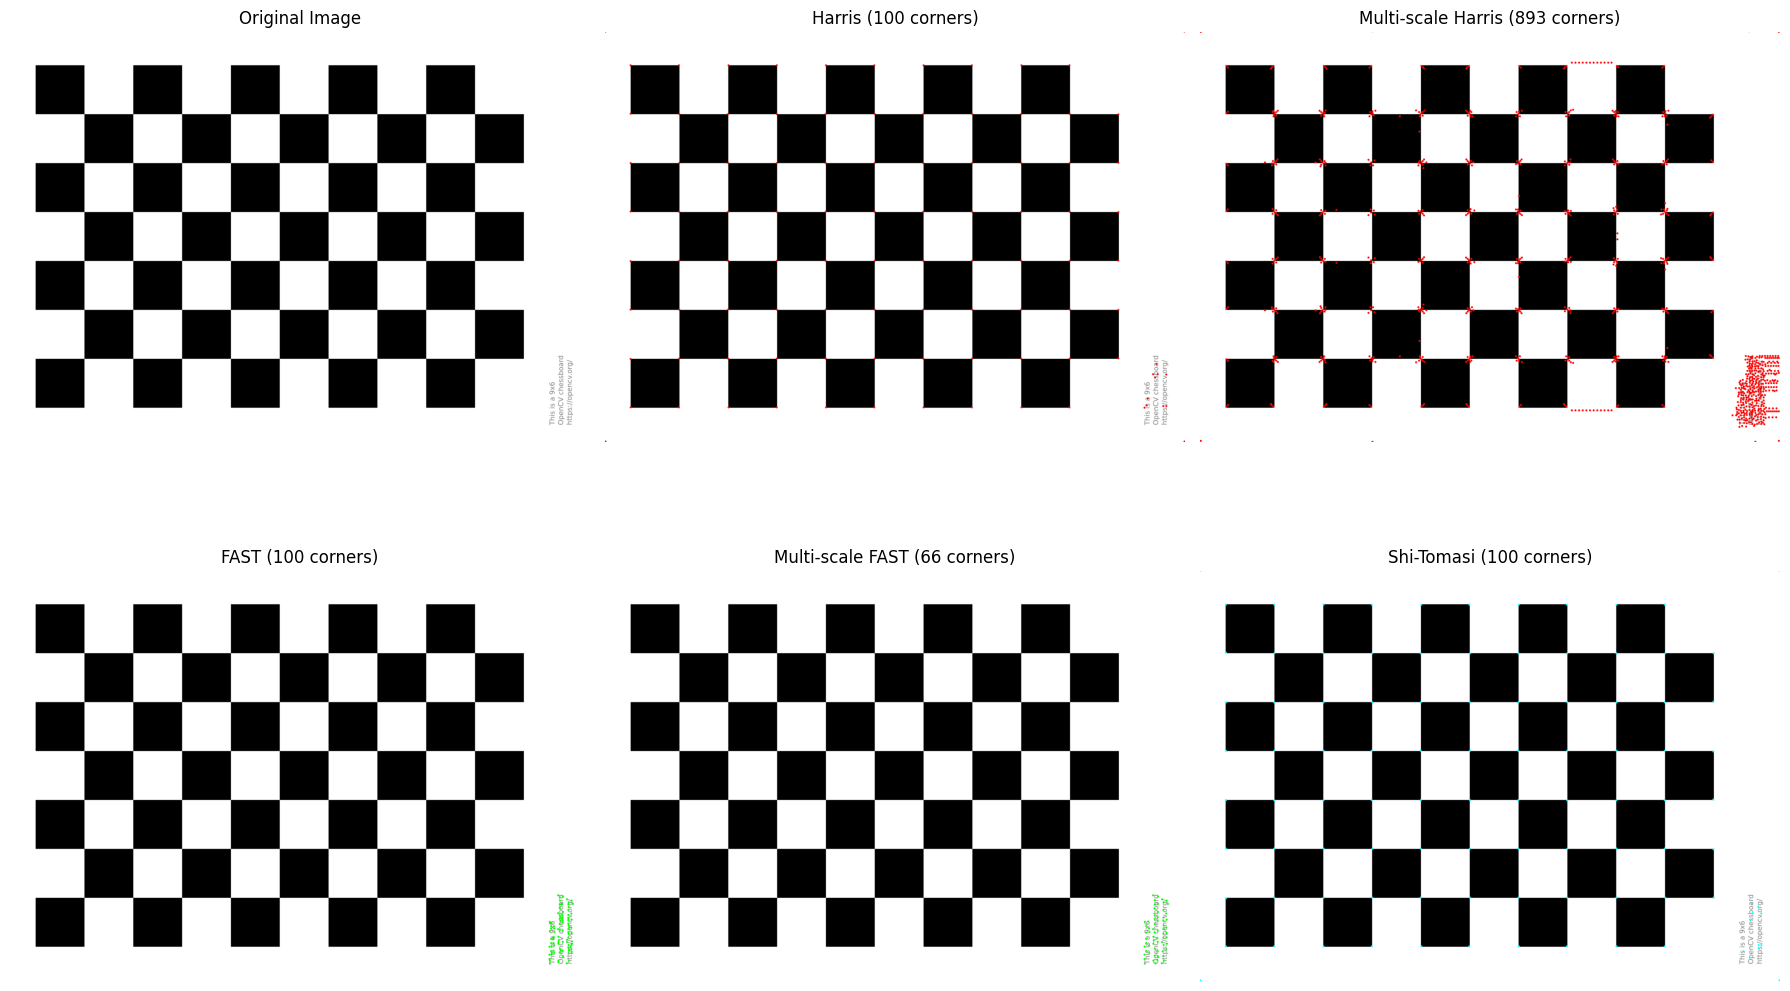


PERFORMANCE COMPARISON
Detector             Time (s)     Corners    Corners/s 
-------------------------------------------------------
Harris               2.892        100        34.6      
Multi-scale Harris   21.152       893        42.2      
FAST                 4.899        100        20.4      
Multi-scale FAST     6.928        66         9.5       
Shi-Tomasi           12.008       100        8.3       

ROTATION INVARIANCE TEST

Testing Harris rotation invariance...


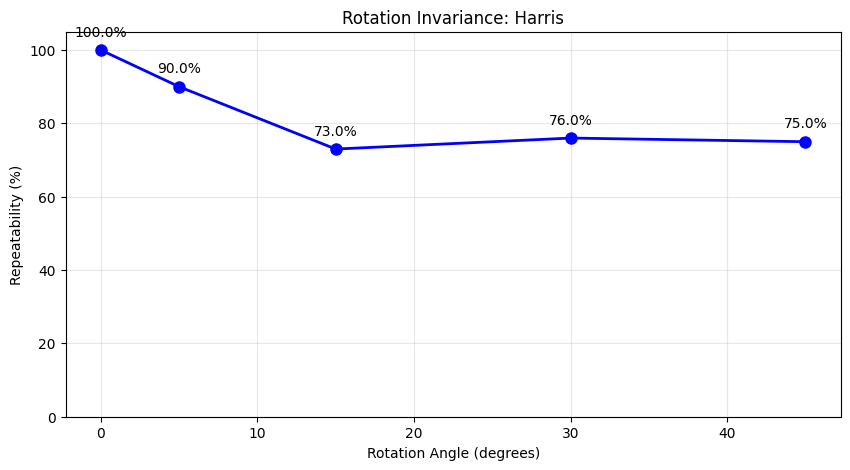


Testing FAST rotation invariance...


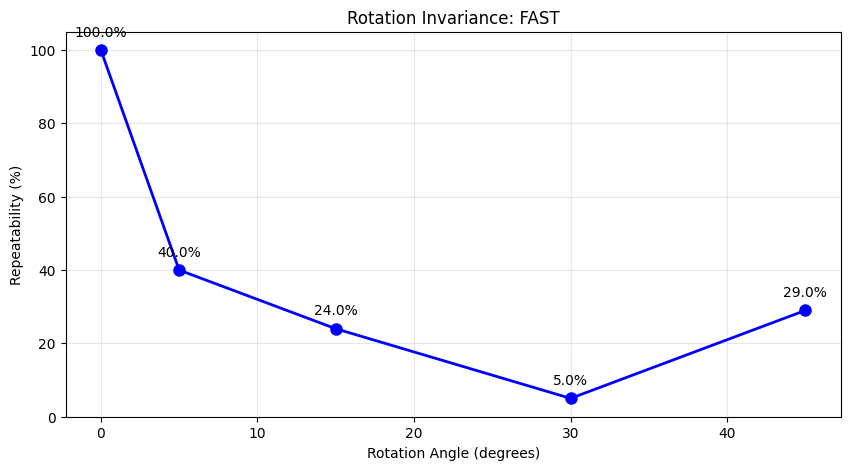


SUMMARY

Harris is more rotation invariant but slower.
FAST is very fast but less rotation invariant.
Multi-scale versions handle scale changes better.

WEBCAM DEMO OPTIONS

1. JavaScript Webcam (requires browser permission)
2. Mock Webcam with Test Images (no webcam needed)
3. Cancel

Select option (1, 2, or 3): 2

Starting Mock Webcam Demo...
MOCK WEBCAM DEMO WITH TEST IMAGES

This demo simulates webcam input using test images.
Use it to test the corner detection algorithms.

Processing chessboard.png...


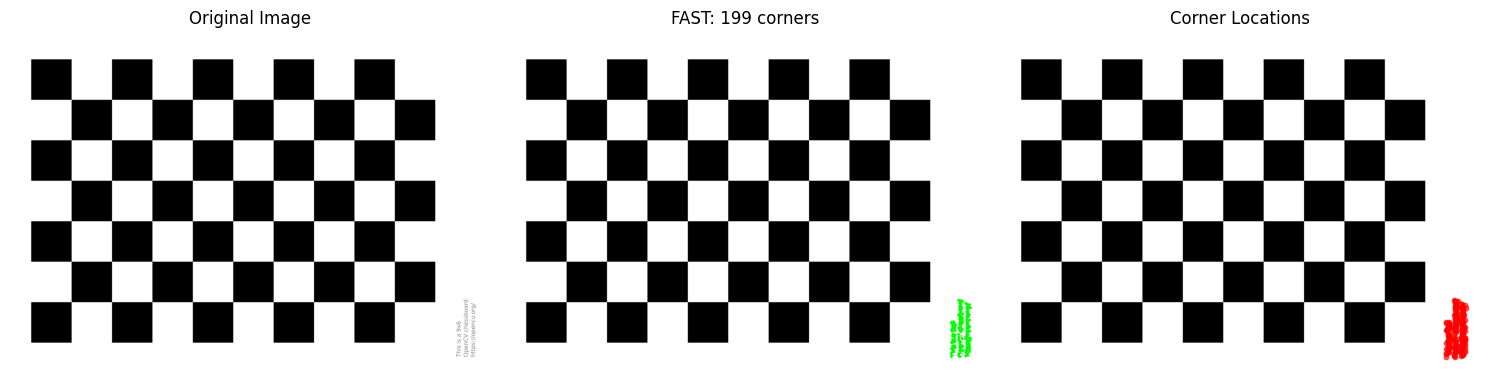


Current: FAST, Threshold: 30
Commands: n=next, h=Harris, f=FAST, +=increase, -=decrease, q=quit: h+

Processing building.jpg...


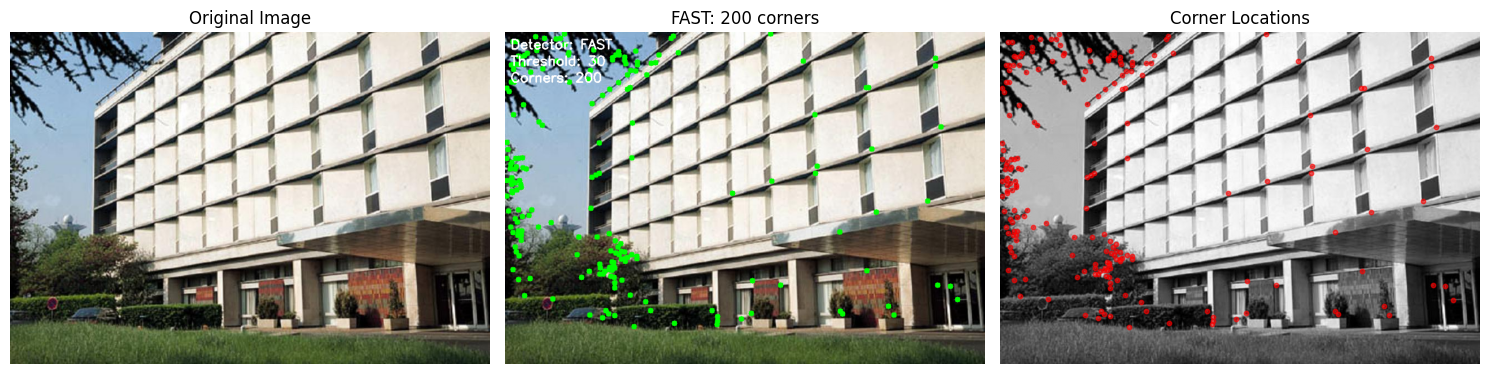


Current: FAST, Threshold: 30
Commands: n=next, h=Harris, f=FAST, +=increase, -=decrease, q=quit: h

Processing blox.jpg...


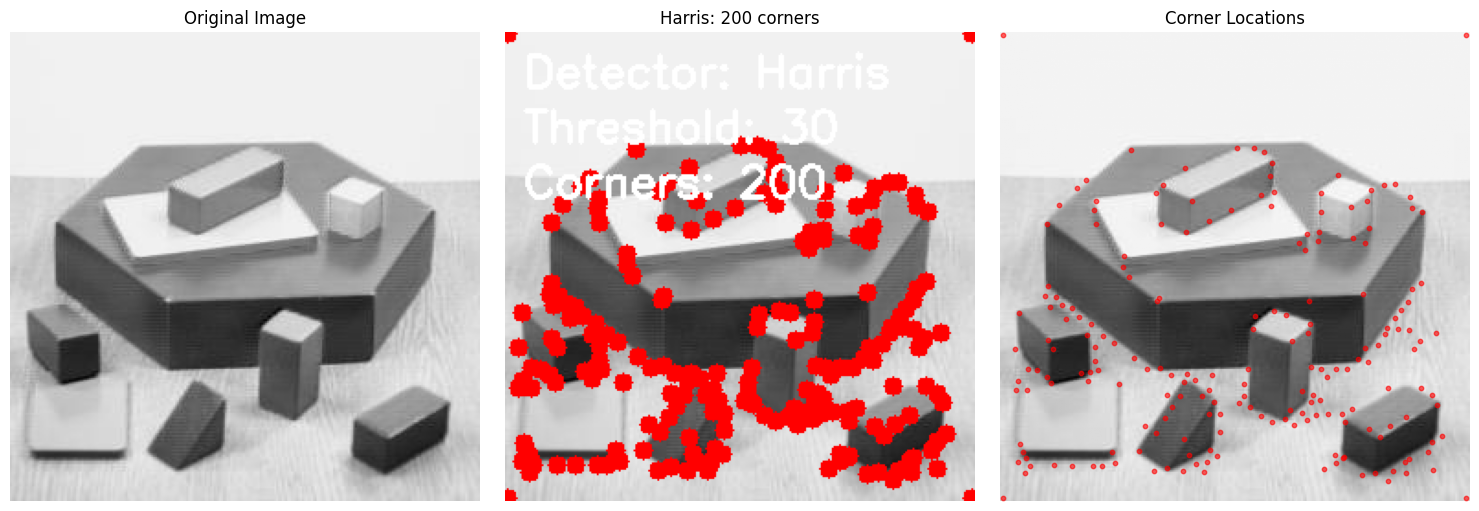

In [ ]:
def main_demo_colab():
    """Main demonstration function for Google Colab."""
    # Download a test image
    test_image_url = "https://raw.githubusercontent.com/opencv/opencv/master/samples/data/chessboard.png"
    test_image_path = "chessboard.png"

    if not os.path.exists(test_image_path):
        print("Downloading test image...")
        urllib.request.urlretrieve(test_image_url, test_image_path)

    # Load image
    img = cv2.imread(test_image_path)
    if img is None:
        print("Error: Could not load test image")
        return

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    print("=" * 60)
    print("FEATURE DETECTOR DEMONSTRATION - GOOGLE COLAB")
    print("=" * 60)

    # Test 1: Harris Corner Detector
    print("\n1. Testing Improved Harris Corner Detector...")
    start_time = time.time()
    harris_corners = harris_corners_improved(
        gray.astype(np.float32),
        block_size=3,
        suppression_radius=5,
        percentile_threshold=97,
        top_n=100,
        subpixel=True
    )
    harris_time = time.time() - start_time
    print(f"   Found {len(harris_corners)} corners in {harris_time:.3f} seconds")

    # Test 2: Multi-scale Harris
    print("\n2. Testing Multi-scale Harris...")
    start_time = time.time()
    ms_harris_corners = multi_scale_harris(
        gray.astype(np.float32),
        scales=[1.0, 1.5, 2.0],
        base_block_size=3,
        suppression_radius=5
    )
    ms_harris_time = time.time() - start_time
    print(f"   Found {len(ms_harris_corners)} corners in {ms_harris_time:.3f} seconds")

    # Test 3: FAST Detector
    print("\n3. Testing Improved FAST Detector...")
    start_time = time.time()
    fast_corners = fast_corners_improved(
        gray,
        threshold=30,
        n=9,
        suppression_radius=3,
        top_n=100,
        score_method="sum_abs_diff"
    )
    fast_time = time.time() - start_time
    print(f"   Found {len(fast_corners)} corners in {fast_time:.3f} seconds")

    # Test 4: Multi-scale FAST
    print("\n4. Testing Multi-scale FAST...")
    start_time = time.time()
    ms_fast_corners = multi_scale_fast(
        gray,
        scales=[1.0, 0.75, 0.5],
        base_threshold=20,
        n=9,
        top_n=100
    )
    ms_fast_time = time.time() - start_time
    print(f"   Found {len(ms_fast_corners)} corners in {ms_fast_time:.3f} seconds")

    # Test 5: Shi-Tomasi
    print("\n5. Testing Shi-Tomasi Corner Detector...")
    start_time = time.time()
    shi_corners = shi_tomasi_corners(
        gray.astype(np.float32),
        block_size=3,
        suppression_radius=5,
        percentile_threshold=97,
        top_n=100
    )
    shi_time = time.time() - start_time
    print(f"   Found {len(shi_corners)} corners in {shi_time:.3f} seconds")

    # Visualization
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))

    detectors = [
        ("Original", img),
        ("Harris", harris_corners),
        ("Multi-scale Harris", ms_harris_corners),
        ("FAST", fast_corners),
        ("Multi-scale FAST", ms_fast_corners),
        ("Shi-Tomasi", shi_corners)
    ]

    titles = ["Original Image",
              f"Harris ({len(harris_corners)} corners)",
              f"Multi-scale Harris ({len(ms_harris_corners)} corners)",
              f"FAST ({len(fast_corners)} corners)",
              f"Multi-scale FAST ({len(ms_fast_corners)} corners)",
              f"Shi-Tomasi ({len(shi_corners)} corners)"]

    for idx, (detector_name, result) in enumerate(detectors):
        row = idx // 3
        col = idx % 3

        if detector_name == "Original":
            axes[row, col].imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
        else:
            vis_img = img.copy()
            for corner in result:
                y, x, *_ = corner
                if detector_name == "FAST" or detector_name == "Multi-scale FAST":
                    color = (0, 255, 0)
                elif detector_name == "Shi-Tomasi":
                    color = (255, 255, 0)
                else:
                    color = (0, 0, 255)

                cv2.circle(vis_img, (int(x), int(y)), 3, color, -1)

            axes[row, col].imshow(cv2.cvtColor(vis_img, cv2.COLOR_BGR2RGB))

        axes[row, col].set_title(titles[idx])
        axes[row, col].axis('off')

    plt.tight_layout()
    plt.show()

    # Timing comparison
    print("\n" + "=" * 60)
    print("PERFORMANCE COMPARISON")
    print("=" * 60)

    detectors_timing = [
        ("Harris", harris_time, len(harris_corners)),
        ("Multi-scale Harris", ms_harris_time, len(ms_harris_corners)),
        ("FAST", fast_time, len(fast_corners)),
        ("Multi-scale FAST", ms_fast_time, len(ms_fast_corners)),
        ("Shi-Tomasi", shi_time, len(shi_corners))
    ]

    print(f"{'Detector':<20} {'Time (s)':<12} {'Corners':<10} {'Corners/s':<10}")
    print("-" * 55)

    for name, t, num in detectors_timing:
        if t > 0:
            cps = num / t
        else:
            cps = 0
        print(f"{name:<20} {t:<12.3f} {num:<10} {cps:<10.1f}")

    # Test rotation invariance
    print("\n" + "=" * 60)
    print("ROTATION INVARIANCE TEST")
    print("=" * 60)

    def harris_wrapper(img):
        corners = harris_corners_improved(img.astype(np.float32), top_n=100)
        return corners

    def fast_wrapper(img):
        corners = fast_corners_improved(img, top_n=100)
        return corners

    print("\nTesting Harris rotation invariance...")
    harris_repeatability = test_rotation_invariance(harris_wrapper, gray, "Harris")

    print("\nTesting FAST rotation invariance...")
    fast_repeatability = test_rotation_invariance(fast_wrapper, gray, "FAST")

    # Summary
    print("\n" + "=" * 60)
    print("SUMMARY")
    print("=" * 60)
    print("\nHarris is more rotation invariant but slower.")
    print("FAST is very fast but less rotation invariant.")
    print("Multi-scale versions handle scale changes better.")

    # Ask for webcam demo
    print("\n" + "=" * 60)
    print("WEBCAM DEMO OPTIONS")
    print("=" * 60)
    print("\n1. JavaScript Webcam (requires browser permission)")
    print("2. Mock Webcam with Test Images (no webcam needed)")
    print("3. Cancel")

    choice = input("\nSelect option (1, 2, or 3): ").strip()

    if choice == "1":
        print("\nStarting JavaScript Webcam Demo...")
        print("Note: You'll need to allow webcam access when prompted.")
        webcam_corner_demo_colab()
    elif choice == "2":
        print("\nStarting Mock Webcam Demo...")
        mock_webcam_demo()
    else:
        print("\nSkipping webcam demo.")

    print("\nDemo completed!")

# Run the main demo
if __name__ == "__main__":
    main_demo_colab()